# Embeddings and Semantic Similarity in Business Applications

In this notebook, we will work with **sentence embeddings**.

Sentence embeddings are numerical representations of entire pieces of text, such as customer reviews, support tickets, emails, or survey responses.

The key idea is that texts with similar meanings should have similar vector representations, even if they use different words.

For example:

> "I received the wrong invoice."  
> "There was a billing mistake on my account."

These sentences use different words, but they describe a similar business issue. A good embedding model should place them close together in the vector space.

In this notebook, we will demonstrate:

- How business texts can be represented as vectors
- How semantic similarity is measured
- How semantic search works
- How customer feedback can be categorized
- How embeddings can support business decision-making


Unlike keyword search, embeddings allow us to search by **meaning** rather than exact words. This makes them particularly useful for customer feedback analysis, support automation, document retrieval, and knowledge management.

**Loading a Pre-trained Sentence Transformer Model**

We will use a pre-trained Sentence Transformer model. The model all-MiniLM-L6-v2 was trained on large collections of text and produces a 384-dimensional vector for each sentence.


We do not train the model ourselves - we load a model that has already learned semantic relationships between texts.


Instead of generating vectors for individual words like GloVe embedding, we generate vectors for complete sentences.

In [7]:
!pip install -q pandas scikit-learn sentence-transformers matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [8]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

# Business Dataset

Suppose we collected customer feedback from an e-commerce company.

Each review contains information about customer experiences with:

- Deliveries
- Invoices
- Payments
- Support
- Mobile applications

In [9]:
# Imagine these are customer reviews collected from a post-purchase survey.

reviews = [
    "The delivery was fast and the product quality exceeded my expectations.",
    "Customer support ignored my complaint for five days.",
    "The mobile app is easy to use, but the payment screen crashes.",
    "The price is competitive, although delivery could be faster.",
    "I received the wrong invoice and nobody explained the issue.",
    "Premium support solved my problem in less than one hour.",
    "The checkout process failed when I tried to pay by credit card.",
    "The package arrived late and the tracking information was unclear.",
    "I was charged twice for the same order.",
    "The chatbot gave helpful answers about my return request."
]

df = pd.DataFrame({"review": reviews})

# Simple metadata can help business users understand the dataset.
df["text_length"] = df["review"].str.len()
df["word_count"] = df["review"].str.split().str.len()

df

,review,text_length,word_count
0,The delivery was fast and the product quality ...,71,11
1,Customer support ignored my complaint for five...,52,8
2,"The mobile app is easy to use, but the payment...",62,12
3,"The price is competitive, although delivery co...",60,9
4,I received the wrong invoice and nobody explai...,60,10
5,Premium support solved my problem in less than...,56,10
6,The checkout process failed when I tried to pa...,63,12
7,The package arrived late and the tracking info...,66,10
8,I was charged twice for the same order.,39,8
9,The chatbot gave helpful answers about my retu...,57,9


# Convert business texts into embeddings

In [10]:
# Similar texts should have similar vectors, even if they use different words.

embeddings = model.encode(
    reviews,
    normalize_embeddings=True
)

print("Number of reviews:", len(reviews))
print("Embedding shape:", embeddings.shape)
print("Each review is represented by", embeddings.shape[1], "numbers.")

Number of reviews: 10
Embedding shape: (10, 384)
Each review is represented by 384 numbers.


# Semantic similarity matrix

In [11]:
# Cosine similarity measures how close two embeddings are.
#
# Score interpretation:
# - close to 1.0: very similar meaning
# - around 0.5: somewhat related
# - close to 0.0: weakly related
# - negative: usually unrelated/opposite in embedding space

similarity_matrix = cosine_similarity(embeddings)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=[f"Review {i+1}" for i in range(len(reviews))],
    columns=[f"Review {i+1}" for i in range(len(reviews))]
)

similarity_df.round(2)

,Review 1,Review 2,Review 3,Review 4,Review 5,Review 6,Review 7,Review 8,Review 9,Review 10
Review 1,1.00,0.29,0.19,0.53,0.27,0.19,0.19,0.39,0.24,0.13
Review 2,0.29,1.00,0.14,0.07,0.43,0.46,0.37,0.32,0.34,0.29
Review 3,0.19,0.14,1.00,0.13,0.16,0.32,0.46,0.05,0.15,0.09
Review 4,0.53,0.07,0.13,1.00,0.14,0.07,-0.01,0.21,0.13,0.03
Review 5,0.27,0.43,0.16,0.14,1.00,0.37,0.37,0.36,0.44,0.22
Review 6,0.19,0.46,0.32,0.07,0.37,1.00,0.38,0.13,0.30,0.23
Review 7,0.19,0.37,0.46,-0.01,0.37,0.38,1.00,0.26,0.35,0.20
Review 8,0.39,0.32,0.05,0.21,0.36,0.13,0.26,1.00,0.28,0.20
Review 9,0.24,0.34,0.15,0.13,0.44,0.30,0.35,0.28,1.00,0.16
Review 10,0.13,0.29,0.09,0.03,0.22,0.23,0.20,0.20,0.16,1.00


In [12]:
# Display the original review IDs for easier interpretation.

review_lookup = pd.DataFrame({
    "review_id": [f"Review {i+1}" for i in range(len(reviews))],
    "review": reviews
})

review_lookup

,review_id,review
0,Review 1,The delivery was fast and the product quality ...
1,Review 2,Customer support ignored my complaint for five...
2,Review 3,"The mobile app is easy to use, but the payment..."
3,Review 4,"The price is competitive, although delivery co..."
4,Review 5,I received the wrong invoice and nobody explai...
5,Review 6,Premium support solved my problem in less than...
6,Review 7,The checkout process failed when I tried to pa...
7,Review 8,The package arrived late and the tracking info...
8,Review 9,I was charged twice for the same order.
9,Review 10,The chatbot gave helpful answers about my retu...


# Visualize semantic similarity

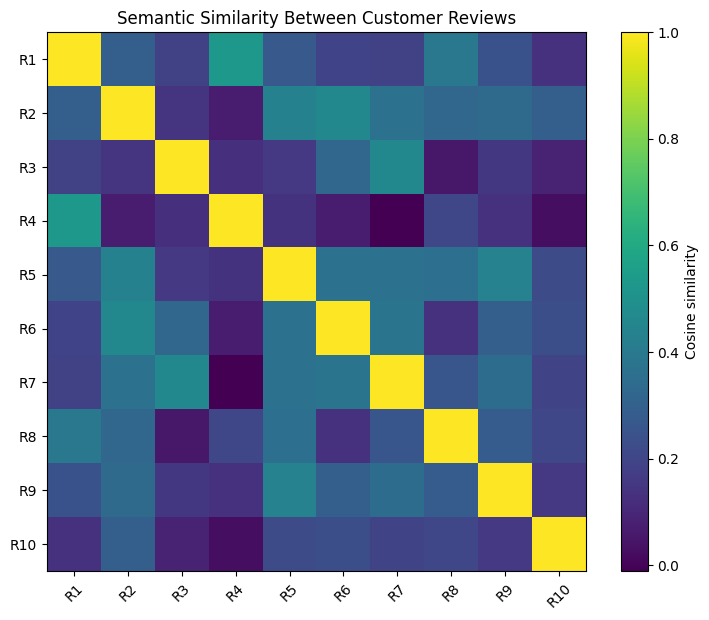

In [13]:
# This heatmap helps to see
# which pieces of feedback are semantically close to each other.

plt.figure(figsize=(9, 7))
plt.imshow(similarity_matrix)
plt.colorbar(label="Cosine similarity")
plt.xticks(range(len(reviews)), [f"R{i+1}" for i in range(len(reviews))], rotation=45)
plt.yticks(range(len(reviews)), [f"R{i+1}" for i in range(len(reviews))])
plt.title("Semantic Similarity Between Customer Reviews")
plt.show()

# Semantic search: find reviews related to a business problem

In [14]:
# Traditional keyword search may miss relevant reviews.
# Example:
# Query: "billing problem with invoice"
# This should find reviews about invoices, charges, payment, and billing,
# even if the exact word "billing" does not appear.

query = "billing problem with invoice"

query_embedding = model.encode(
    [query],
    normalize_embeddings=True
)

scores = cosine_similarity(query_embedding, embeddings)[0]

results = pd.DataFrame({
    "review": reviews,
    "similarity_score": scores
}).sort_values("similarity_score", ascending=False)

results.round(3)

,review,similarity_score
4,I received the wrong invoice and nobody explai...,0.668
6,The checkout process failed when I tried to pa...,0.375
8,I was charged twice for the same order.,0.371
5,Premium support solved my problem in less than...,0.283
1,Customer support ignored my complaint for five...,0.246
7,The package arrived late and the tracking info...,0.209
2,"The mobile app is easy to use, but the payment...",0.187
0,The delivery was fast and the product quality ...,0.132
3,"The price is competitive, although delivery co...",0.131
9,The chatbot gave helpful answers about my retu...,0.078


# Make results easier for business users to read

In [15]:
def semantic_search(query, texts, embeddings, model, top_k=5):
    """
    Search for the most semantically similar texts.

    Parameters
    ----------
    query : str
        Business question or issue, e.g. "payment failed".
    texts : list[str]
        Documents, reviews, tickets, or comments.
    embeddings : np.ndarray
        Precomputed embeddings for texts.
    model : SentenceTransformer
        Local embedding model.
    top_k : int
        Number of most relevant results to return.

    Returns
    -------
    pd.DataFrame
        Ranked results with similarity scores.
    """

    query_embedding = model.encode(
        [query],
        normalize_embeddings=True
    )

    similarity_scores = cosine_similarity(query_embedding, embeddings)[0]

    result_df = pd.DataFrame({
        "rank": range(1, len(texts) + 1),
        "review": texts,
        "similarity_score": similarity_scores
    })

    result_df = result_df.sort_values(
        "similarity_score",
        ascending=False
    ).head(top_k)

    result_df["rank"] = range(1, len(result_df) + 1)

    return result_df


semantic_search(
    query="customers having problems with payments",
    texts=reviews,
    embeddings=embeddings,
    model=model,
    top_k=5
).round(3)

,rank,review,similarity_score
6,1,The checkout process failed when I tried to pa...,0.474
1,2,Customer support ignored my complaint for five...,0.424
4,3,I received the wrong invoice and nobody explai...,0.373
2,4,"The mobile app is easy to use, but the payment...",0.343
5,5,Premium support solved my problem in less than...,0.320


# Compare keyword search vs semantic search

In [16]:
# keyword search only finds exact words,
# while embeddings find meaning.

def keyword_search(keyword, texts):
    """
    Very simple keyword search.
    """
    keyword = keyword.lower()

    matches = [
        text for text in texts
        if keyword in text.lower()
    ]

    return pd.DataFrame({"keyword_match": matches})


print("Keyword search for 'billing':")
display(keyword_search("billing", reviews))

print("Semantic search for 'billing problem':")
display(
    semantic_search(
        query="billing problem",
        texts=reviews,
        embeddings=embeddings,
        model=model,
        top_k=5
    ).round(3)
)

Keyword search for 'billing':


,keyword_match


Semantic search for 'billing problem':


,rank,review,similarity_score
6,1,The checkout process failed when I tried to pa...,0.485
4,2,I received the wrong invoice and nobody explai...,0.444
8,3,I was charged twice for the same order.,0.382
5,4,Premium support solved my problem in less than...,0.351
2,5,"The mobile app is easy to use, but the payment...",0.323


# Business category detection using semantic similarity

In [17]:
# We can classify feedback into business themes without training a model.
# This is useful when you have no labeled dataset.

business_categories = {
    "Delivery and logistics": "late delivery, slow shipping, tracking problem, package issue",
    "Billing and invoices": "wrong invoice, payment problem, overcharged, charged twice",
    "Customer support": "support ignored complaint, slow response, helpful support",
    "App and checkout experience": "mobile app crash, checkout failed, payment screen problem",
    "Pricing and value": "price, discount, competitive pricing, expensive product"
}

category_names = list(business_categories.keys())
category_descriptions = list(business_categories.values())

category_embeddings = model.encode(
    category_descriptions,
    normalize_embeddings=True
)

category_scores = cosine_similarity(embeddings, category_embeddings)

predicted_category_index = np.argmax(category_scores, axis=1)
predicted_category_score = np.max(category_scores, axis=1)

df["predicted_category"] = [
    category_names[i] for i in predicted_category_index
]

df["category_confidence"] = predicted_category_score

df[["review", "predicted_category", "category_confidence"]].round(3)

,review,predicted_category,category_confidence
0,The delivery was fast and the product quality ...,Delivery and logistics,0.494
1,Customer support ignored my complaint for five...,Customer support,0.601
2,"The mobile app is easy to use, but the payment...",App and checkout experience,0.763
3,"The price is competitive, although delivery co...",Pricing and value,0.533
4,I received the wrong invoice and nobody explai...,Billing and invoices,0.639
5,Premium support solved my problem in less than...,Customer support,0.484
6,The checkout process failed when I tried to pa...,App and checkout experience,0.575
7,The package arrived late and the tracking info...,Delivery and logistics,0.666
8,I was charged twice for the same order.,Billing and invoices,0.593
9,The chatbot gave helpful answers about my retu...,Customer support,0.343


# Summarize business insights

In [18]:
# This converts embeddings into something useful for managers:
# "What are customers talking about most?"

category_summary = (
    df.groupby("predicted_category")
    .agg(
        number_of_reviews=("review", "count"),
        average_confidence=("category_confidence", "mean")
    )
    .sort_values("number_of_reviews", ascending=False)
)

category_summary.round(3)

,number_of_reviews,average_confidence
predicted_category,,
Customer support,3,0.476
App and checkout experience,2,0.669
Billing and invoices,2,0.616
Delivery and logistics,2,0.580
Pricing and value,1,0.533


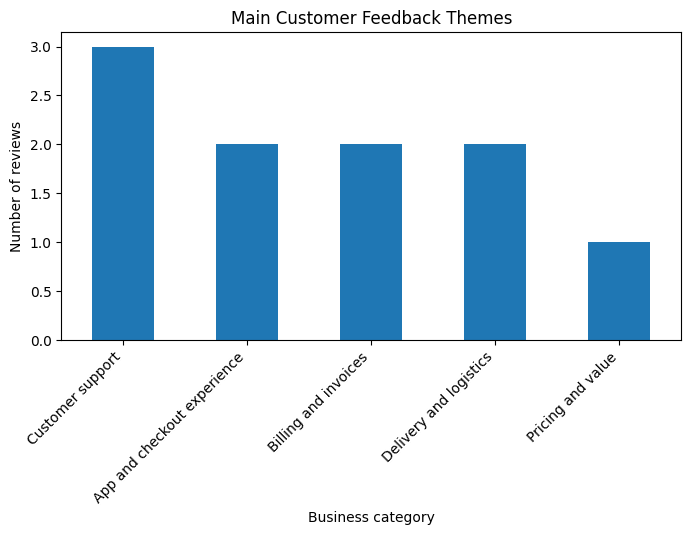

In [20]:
# Simple bar chart for visualization

category_summary["number_of_reviews"].plot(kind="bar", figsize=(8, 4))

plt.title("Main Customer Feedback Themes")
plt.xlabel("Business category")
plt.ylabel("Number of reviews")
plt.xticks(rotation=45, ha="right")
plt.show()

# Find duplicates or near-duplicates

In [21]:
# Detect repeated complaints, repeated support tickets,
# or similar customer issues across channels.

pairs = []

for i in range(len(reviews)):
    for j in range(i + 1, len(reviews)):
        pairs.append({
            "review_1": reviews[i],
            "review_2": reviews[j],
            "similarity": similarity_matrix[i, j]
        })

similar_pairs = (
    pd.DataFrame(pairs)
    .sort_values("similarity", ascending=False)
)

similar_pairs.head(10).round(3)

,review_1,review_2,similarity
2,The delivery was fast and the product quality ...,"The price is competitive, although delivery co...",0.528
20,"The mobile app is easy to use, but the payment...",The checkout process failed when I tried to pa...,0.462
12,Customer support ignored my complaint for five...,Premium support solved my problem in less than...,0.461
33,I received the wrong invoice and nobody explai...,I was charged twice for the same order.,0.437
11,Customer support ignored my complaint for five...,I received the wrong invoice and nobody explai...,0.432
6,The delivery was fast and the product quality ...,The package arrived late and the tracking info...,0.393
35,Premium support solved my problem in less than...,The checkout process failed when I tried to pa...,0.376
30,I received the wrong invoice and nobody explai...,Premium support solved my problem in less than...,0.369
31,I received the wrong invoice and nobody explai...,The checkout process failed when I tried to pa...,0.367
13,Customer support ignored my complaint for five...,The checkout process failed when I tried to pa...,0.367


# Business interpretation

In [22]:
# Similarity scores help prioritize what humans should inspect first.

def interpret_similarity(score):
    if score >= 0.70:
        return "Very similar"
    elif score >= 0.50:
        return "Related"
    elif score >= 0.30:
        return "Weakly related"
    else:
        return "Probably unrelated"


similar_pairs["interpretation"] = similar_pairs["similarity"].apply(interpret_similarity)

similar_pairs.head(10).round(3)

,review_1,review_2,similarity,interpretation
2,The delivery was fast and the product quality ...,"The price is competitive, although delivery co...",0.528,Related
20,"The mobile app is easy to use, but the payment...",The checkout process failed when I tried to pa...,0.462,Weakly related
12,Customer support ignored my complaint for five...,Premium support solved my problem in less than...,0.461,Weakly related
33,I received the wrong invoice and nobody explai...,I was charged twice for the same order.,0.437,Weakly related
11,Customer support ignored my complaint for five...,I received the wrong invoice and nobody explai...,0.432,Weakly related
6,The delivery was fast and the product quality ...,The package arrived late and the tracking info...,0.393,Weakly related
35,Premium support solved my problem in less than...,The checkout process failed when I tried to pa...,0.376,Weakly related
30,I received the wrong invoice and nobody explai...,Premium support solved my problem in less than...,0.369,Weakly related
31,I received the wrong invoice and nobody explai...,The checkout process failed when I tried to pa...,0.367,Weakly related
13,Customer support ignored my complaint for five...,The checkout process failed when I tried to pa...,0.367,Weakly related


# TASK
Try your own business queries.

Suggested queries:
- "payment and checkout problems"
- "customers complain about slow support"
- "delivery delays"
- "positive support experience"
- "pricing concerns"

In [24]:
# For example:
query = "payment and checkout problems"

semantic_search(
    query=query,
    texts=reviews,
    embeddings=embeddings,
    model=model,
    top_k=5
).round(3)

,rank,review,similarity_score
6,1,The checkout process failed when I tried to pa...,0.578
2,2,"The mobile app is easy to use, but the payment...",0.380
4,3,I received the wrong invoice and nobody explai...,0.357
8,4,I was charged twice for the same order.,0.302
5,5,Premium support solved my problem in less than...,0.282
